In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  

proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
import torch
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
import importlib
# import util
# importlib.reload(util)
import json
import open_clip
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# import numpy as np

# # 指定根目录
# # directory = '/home/ldy/Closed_loop_optimizing/server/outputs/yiming_male_2/clip'
# directory = '/home/ldy/Closed_loop_optimizing/server/outputs/suyu_male_1/psd/'
# # directory = '/home/ldy/Closed_loop_optimizing/server/outputs/zhouyijun_female_2/clip/'

# # 收集所有JSON文件中的列表内容
# rewards = np.load(os.path.join(directory, "all_viewed_image_rewards.npy"), allow_pickle=True)

# # 打印结果或进行其他处理
# print(f"总共收集了 {len(rewards)} 个元素")

In [3]:
import os
import numpy as np
import random
from typing import Dict

def load_feature_arrays(root_dir: str, feature_type: str, npy_filename: str = "all_viewed_image_rewards.npy") -> Dict[str, np.ndarray]:
    """
    从指定根目录加载特定feature_type的所有array
    
    参数:
        root_dir: 根目录路径
        feature_type: 特征类型，可以是"clip", "psd"或"rating"
        npy_filename: 要加载的npy文件名，默认为"all_viewed_image_rewards.npy"
    
    返回:
        一个字典，键是被试编号，值是对应的numpy array
    """
    feature_arrays = {}
    
    # 遍历根目录下的所有子目录
    for sub_dir in os.listdir(root_dir):
        sub_dir_path = os.path.join(root_dir, sub_dir)
        
        # 检查是否是目录
        if os.path.isdir(sub_dir_path):
            # 构建feature_type目录路径
            feature_dir = os.path.join(sub_dir_path, feature_type)
            
            # 检查feature_type目录是否存在
            if os.path.exists(feature_dir):
                npy_file = os.path.join(feature_dir, npy_filename)
                
                # 检查npy文件是否存在并加载
                if os.path.exists(npy_file):
                    try:
                        array = np.load(npy_file, allow_pickle=True)
                        feature_arrays[sub_dir] = array
                    except Exception as e:
                        print(f"Error loading {npy_file}: {e}")
                else:
                    print(f"File not found: {npy_file}")
    
    return feature_arrays

In [4]:
def extract_elements(subject_arrays: Dict[str, np.ndarray]) -> np.ndarray:
    """
    从每个被试的数组中提取三个特定元素并合并
    
    参数:
        subject_arrays: 包含所有被试数组的字典
    
    返回:
        合并后的numpy数组
    """
    result_list = []
    
    for sub_id, array in subject_arrays.items():
        if len(array) == 0:
            continue        
        
        # 将三个值组成小数组并添加到结果列表
        result_list.append(array)
    
    # 将所有被试的小数组合并成一个大的numpy数组
    if result_list:
        return np.vstack(result_list)
    else:
        return np.array([])

In [5]:
root_dir = "/home/ldy/Closed_loop_optimizing/server/outputs"

# 可以改变这个值来获取不同类型的特征
feature_type = "clip"  # 可以改为"psd"

# 定义要剔除的被试ID关键词列表
exclude_keywords = ['yichen', 'luwenbin', 'shenyuyang', 'gaoyiou']  # 你可以根据需要修改这个列表


In [6]:

# 加载奖励数据并处理
print("\nProcessing rewards data...")
reward_arrays = load_feature_arrays(root_dir, feature_type, npy_filename="all_viewed_image_rewards.npy")

# 过滤掉包含关键词的被试
filtered_reward_arrays = {
    sub_id: array 
    for sub_id, array in reward_arrays.items() 
    if not any(keyword in str(sub_id).lower() for keyword in exclude_keywords)
}

# 打印原始奖励数据信息
print(f"\nLoaded {len(filtered_reward_arrays)} subjects' {feature_type} reward arrays after filtering:")
for sub_id, array in filtered_reward_arrays.items():
    print(f"Subject {sub_id}: array shape {array.shape}")

# 提取并合并奖励元素
final_reward_array = extract_elements(filtered_reward_arrays)

# 打印最终奖励结果
print("\nFinal combined reward array:")
print(final_reward_array)
if final_reward_array.size > 0:
    print(f"Shape: {final_reward_array.shape}")


Processing rewards data...

Loaded 12 subjects' clip reward arrays after filtering:
Subject zhaoquanbo_male_1: array shape (64,)
Subject suyu_male_1: array shape (64,)
Subject yiming_male_1: array shape (64,)
Subject zhaoquanbo_male_2: array shape (64,)
Subject mingjie_female_1: array shape (64,)
Subject suyu_male_2: array shape (64,)
Subject zhouyijun_female_1: array shape (64,)
Subject mingjie_female_2: array shape (64,)
Subject yuanjiamu_female_2: array shape (64,)
Subject yiming_male_2: array shape (64,)
Subject zhouyijun_female_2: array shape (64,)
Subject yuanjiamu_female_1: array shape (64,)

Final combined reward array:
[[0.5596739649772644 0.6841472387313843 0.49029356241226196
  0.5219808220863342 0.605771005153656 0.5492593050003052
  0.7083527445793152 0.5189833045005798 0.5790469646453857
  0.6963638663291931 0.6233410835266113 0.6958192586898804
  0.5672255158424377 0.5343182682991028 0.5483452081680298
  0.633624792098999 0.6554843783378601 0.680925726890564
  0.5958893

In [7]:

# 加载评分数据并处理
print("\nProcessing ratings data...")
rating_arrays = load_feature_arrays(root_dir, feature_type, npy_filename="all_viewed_image_ratings.npy")

# 过滤掉包含关键词的被试
filtered_rating_arrays = {
    sub_id: array 
    for sub_id, array in rating_arrays.items() 
    if not any(keyword in str(sub_id).lower() for keyword in exclude_keywords)
}

# 打印原始评分数据信息
print(f"\nLoaded {len(filtered_rating_arrays)} subjects' {feature_type} rating arrays after filtering:")
for sub_id, array in filtered_rating_arrays.items():
    print(f"Subject {sub_id}: array shape {array.shape}")

# 提取并合并评分元素
final_rating_array = extract_elements(filtered_rating_arrays)

# 打印最终评分结果
print("\nFinal combined rating array:")
print(final_rating_array)
if final_rating_array.size > 0:
    print(f"Shape: {final_rating_array.shape}")


Processing ratings data...

Loaded 12 subjects' clip rating arrays after filtering:
Subject zhaoquanbo_male_1: array shape (64,)
Subject suyu_male_1: array shape (64,)
Subject yiming_male_1: array shape (64,)
Subject zhaoquanbo_male_2: array shape (64,)
Subject mingjie_female_1: array shape (64,)
Subject suyu_male_2: array shape (64,)
Subject zhouyijun_female_1: array shape (64,)
Subject mingjie_female_2: array shape (64,)
Subject yuanjiamu_female_2: array shape (64,)
Subject yiming_male_2: array shape (64,)
Subject zhouyijun_female_2: array shape (64,)
Subject yuanjiamu_female_1: array shape (64,)

Final combined rating array:
[[0.45 0.6 0.1 0.1 0.13 0.2 0.15 0.6 0.3 0.43 0.3 0.25 0.22 0.3 0.18 0.22
  0.26 0.27 0.66 0.32 0.2 0.45 0.65 0.45 0.23 0.25 0.05 0.08 0.35 0.32
  0.35 0.88 0.62 0.75 0.8 0.78 0.25 0.79 0.75 0.23 0.26 0.19 0.35 0.36
  0.26 0.2 0.56 0.59 0.58 0.09 0.12 0.14 0.45 0.42 0.56 0.8 0.45 0.78 0.1
  0.05 0.3 0.1 0.05 0.4]
 [0.3 0.5 0.05 0.05 0.2 0.05 0.05 0.05 0.1 0.05 

共计算了 12 个相关系数
平均相关系数: -0.018
相关系数中位数: 0.036
相关系数标准差: 0.145
相关系数范围: [-0.368, 0.138]


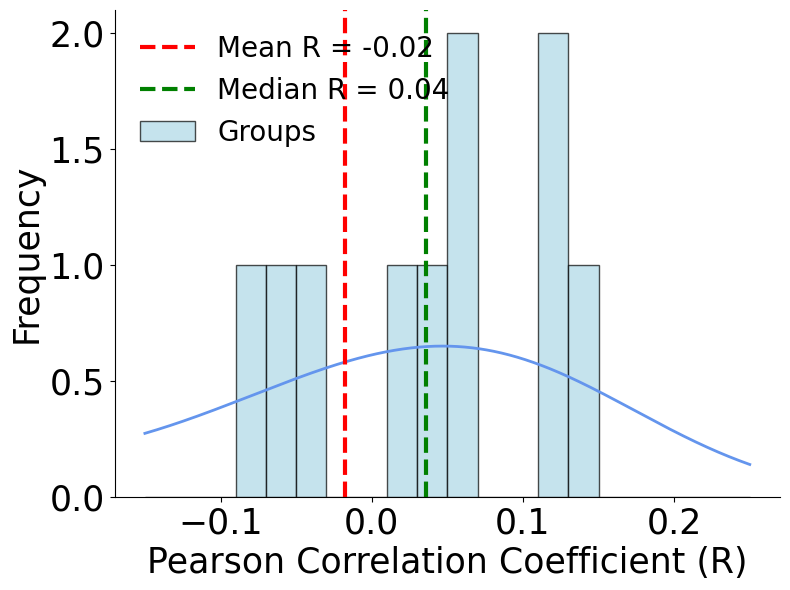

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde



# 计算皮尔逊相关系数
r_values = []
for i in range(final_reward_array.shape[0]):  # 假设第一个维度是样本数
    r, _ = stats.pearsonr(final_reward_array[i], final_rating_array[i])
    r_values.append(r)

r_values = np.array(r_values)

# 统计信息
print(f"共计算了 {len(r_values)} 个相关系数")
print(f"平均相关系数: {np.mean(r_values):.3f}")
print(f"相关系数中位数: {np.median(r_values):.3f}")
print(f"相关系数标准差: {np.std(r_values):.3f}")
print(f"相关系数范围: [{np.min(r_values):.3f}, {np.max(r_values):.3f}]")

# 绘制直方图
plt.figure(figsize=(8, 6))
n_bins = 20  # 可以调整这个值改变分箱数量

# 计算直方图
counts, bin_edges = np.histogram(r_values, bins=n_bins, range=(-0.15, 0.25))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# 绘制柱状图
plt.bar(bin_centers, counts, width=bin_width, 
        align='center', edgecolor='k', alpha=0.7, color='lightblue' , label='Groups')

# 计算并绘制KDE曲线
kde = gaussian_kde(r_values)
x_grid = np.linspace(-0.15, 0.25, 1000)
kde_values = kde(x_grid) * len(r_values) * (bin_edges[1]-bin_edges[0])  # 缩放以匹配直方图高度
plt.plot(x_grid, kde_values, color='cornflowerblue', linewidth=2)

# 添加平均线
mean_r = np.mean(r_values)
plt.axvline(mean_r, color='r', linestyle='dashed', linewidth=3,
            label=f'Mean R = {mean_r:.2f}')

# 添加中位数线
median_r = np.median(r_values)
plt.axvline(median_r, color='g', linestyle='dashed', linewidth=3,
            label=f'Median R = {median_r:.2f}')
# 移除顶部和右侧边框
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
plt.tick_params(axis='both', which='major', labelsize=25)
# 美化图表
plt.xlabel('Pearson Correlation Coefficient (R)', fontsize=25)
plt.ylabel('Frequency', fontsize=25)
plt.legend(frameon=False, fontsize=20, loc='upper left')
plt.grid(False)
# 显示图表
plt.tight_layout()
plt.savefig(f"/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/R_distribution_{feature_type}", dpi=300)
plt.show()

In [9]:
# 对相关系数进行从大到小排序
sorted_r_values = np.sort(r_values)[::-1]  # [::-1]实现从大到小排序

# 打印排序后的相关系数
print("相关系数从大到小排序：")
for i, r in enumerate(sorted_r_values, 1):
    print(f"{i}. {r:.3f}")

# 特别关注最小的10个相关系数
print("\n最小的10个相关系数：")
for i, r in enumerate(sorted_r_values[-10:], 1):
    print(f"{i}. {r:.3f}")

相关系数从大到小排序：
1. 0.138
2. 0.126
3. 0.116
4. 0.060
5. 0.054
6. 0.050
7. 0.022
8. -0.043
9. -0.063
10. -0.082
11. -0.225
12. -0.368

最小的10个相关系数：
1. 0.116
2. 0.060
3. 0.054
4. 0.050
5. 0.022
6. -0.043
7. -0.063
8. -0.082
9. -0.225
10. -0.368


In [10]:
# 获取排序后的索引（从小到大）
sorted_indices = np.argsort(r_values)

# 获取相关系数最小的10个样本的索引
smallest_r_indices = sorted_indices[:10]

print("\n相关系数最小的10个样本的索引：")
print(smallest_r_indices)

# 打印这些样本的具体相关系数
print("\n这些样本的相关系数值：")
print(r_values[smallest_r_indices])


相关系数最小的10个样本的索引：
[7 8 4 9 3 2 0 5 6 1]

这些样本的相关系数值：
[-0.36767402 -0.22546188 -0.08242556 -0.06285889 -0.04315162  0.0222279
  0.04972644  0.05354946  0.05990367  0.11624657]


In [11]:
subject_r_pairs = [(sub_id, r) for sub_id, r in zip(rating_arrays.keys(), r_values)]


# 按相关系数从高到低排序
sorted_pairs = sorted(subject_r_pairs, key=lambda x: x[1], reverse=True)

# 打印排序后的结果
print("\n被试相关系数从高到低排序：")
for i, (sub_id, r) in enumerate(sorted_pairs, 1):
    print(f"{i}. 被试 {sub_id}: 相关系数 {r:.3f}")

# 打印最低的10个相关系数
print("\n相关系数最低的10个被试：")
for i, (sub_id, r) in enumerate(sorted_pairs[-10:], 1):
    print(f"{i}. 被试 {sub_id}: 相关系数 {r:.3f}")


被试相关系数从高到低排序：
1. 被试 shenyuyang_male_1: 相关系数 0.138
2. 被试 zhouyijun_female_1: 相关系数 0.126
3. 被试 suyu_male_1: 相关系数 0.116
4. 被试 mingjie_female_1: 相关系数 0.060
5. 被试 luwenbin_male_1: 相关系数 0.054
6. 被试 zhaoquanbo_male_1: 相关系数 0.050
7. 被试 yichen_male_2: 相关系数 0.022
8. 被试 yiming_male_1: 相关系数 -0.043
9. 被试 gaoyiou_female_2: 相关系数 -0.063
10. 被试 zhaoquanbo_male_2: 相关系数 -0.082
11. 被试 yichen_male_1: 相关系数 -0.225
12. 被试 suyu_male_2: 相关系数 -0.368

相关系数最低的10个被试：
1. 被试 suyu_male_1: 相关系数 0.116
2. 被试 mingjie_female_1: 相关系数 0.060
3. 被试 luwenbin_male_1: 相关系数 0.054
4. 被试 zhaoquanbo_male_1: 相关系数 0.050
5. 被试 yichen_male_2: 相关系数 0.022
6. 被试 yiming_male_1: 相关系数 -0.043
7. 被试 gaoyiou_female_2: 相关系数 -0.063
8. 被试 zhaoquanbo_male_2: 相关系数 -0.082
9. 被试 yichen_male_1: 相关系数 -0.225
10. 被试 suyu_male_2: 相关系数 -0.368
